# Grouped-Target Model Evaluation, SHAP & LIME

Evaluates the multi-output classification pipelines saved in `models/` that operate on the
**grouped** clinical outcomes (`bleeding` / `ischemic` / `generally`) — i.e. the `*_gf_*`
models trained in `bi-class/01_grouped_ML.ipynb`, `mono-class/01_grouped_ML_lDAPT.ipynb` and
`mono-class/01_grouped_ML_sDAPT.ipynb`. Models trained on the 9 individual (ungrouped)
endpoints (`*_sf_*`) are out of scope for this notebook.

For each of the 9 saved pipelines (Logistic Regression / Random Forest / Gradient Boosting ×
full cohort / prolonged DAPT / abbreviated DAPT) this notebook:

1. rebuilds the matching train/test split and reports held-out classification performance per target,
2. computes **SHAP** values to rank global feature importance per target,
3. uses **LIME** to explain individual predictions.

**Note:** the saved pipelines are fit against the feature schema of `X_features.parquet` at
training time. If that file has since changed (columns added/removed/renamed by the data
cleaning pipeline), the cells below will raise a feature-mismatch error until the affected
models are retrained on the current data.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import shap
from lime.lime_tabular import LimeTabularExplainer

PROJECT_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
MODULE_DIR = os.path.join(PROJECT_DIR, 'simple_ml_models')
sys.path.append(MODULE_DIR)

from pipeline_utils import predict_with_threshold, get_estimators_and_data, event_rate_thresholds

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset & Rebuild Grouped Targets

Load the cleaned feature matrix and the 9 individual endpoints, then regroup them into the
same three broad outcomes used for training — *any bleeding event*, *any ischemic event* and
*any event at all* — for each of the three cohort variants (full cohort, prolonged DAPT,
abbreviated DAPT). The train/test split mirrors the corresponding training notebook
(`test_size=0.2`, `random_state=42`) so the held-out rows line up with what each saved
pipeline was evaluated on.

In [2]:
X_full = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y_full = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

bleeding_targets = ['cec_barc3_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc235_335d', 'cec_bleed_335d']
ischemic_targets = [col for col in y_full.columns if col not in bleeding_targets]


def make_grouped_targets(y_df):
    y_bleeding = y_df[bleeding_targets].sum(axis=1).clip(0, 1)
    y_ischemic = y_df[ischemic_targets].sum(axis=1).clip(0, 1)
    y_generally = y_df.sum(axis=1).clip(0, 1)
    return pd.concat(
        [y_bleeding, y_ischemic, y_generally],
        keys=['bleeding', 'ischemic', 'generally'], axis=1,
    )


def build_data_variant(regimen=None):
    # regimen=None -> bi-class/01_grouped_ML.ipynb (full cohort)
    # regimen='prolonged DAPT' -> mono-class/01_grouped_ML_lDAPT.ipynb
    # regimen='abbreviated DAPT' -> mono-class/01_grouped_ML_sDAPT.ipynb
    X = X_full.copy()
    if regimen is not None:
        X = X[X['regimen'] == regimen].copy()
    y_grouped = make_grouped_targets(y_full.loc[X.index])
    X = X.select_dtypes(include=[np.number])  # keep numeric features only
    return train_test_split(X, y_grouped, test_size=0.2, random_state=42)


VARIANT_LABELS = {'_lDAPT': 'prolonged DAPT', '_sDAPT': 'abbreviated DAPT'}
REGIMENS = {'_lDAPT': 'prolonged DAPT', '_sDAPT': 'abbreviated DAPT'}

DATA_VARIANTS = {suffix: build_data_variant(REGIMENS[suffix]) for suffix in VARIANT_LABELS}
TARGET_NAMES = ['bleeding', 'ischemic', 'generally']

## Load the Grouped-Target ("`_gf_`") Pipelines

Load the 9 saved pipelines that were trained on the grouped targets: 3 algorithms
(Logistic Regression, Random Forest, Gradient Boosting) × 3 cohort variants
(full / prolonged DAPT / abbreviated DAPT). The `_sf_` pipelines, trained on the 9
individual endpoints rather than the grouped ones, are intentionally excluded.

In [3]:
MODELS_DIR = os.path.join(MODULE_DIR, 'models')

ALGOS = [
    {'algo': 'LR', 'label': 'Logistic Regression'},
    {'algo': 'RF', 'label': 'Random Forest'},
    {'algo': 'GB', 'label': 'Gradient Boosting'},
]

models = {}
for spec in ALGOS:
    for suffix, variant_label in VARIANT_LABELS.items():
        model_name = f"{spec['algo']}_gf_multioutput{suffix}"
        path = os.path.join(MODELS_DIR, f'{model_name}.joblib')
        try:
            models[model_name] = {
                'pipeline': joblib.load(path),
                'algo': spec['algo'],
                'algo_label': spec['label'],
                'variant': suffix,
                'variant_label': variant_label,
            }
        except FileNotFoundError as e:
            print(e)
            continue


list(models.keys())

['LR_gf_multioutput_lDAPT',
 'LR_gf_multioutput_sDAPT',
 'RF_gf_multioutput_lDAPT',
 'RF_gf_multioutput_sDAPT',
 'GB_gf_multioutput_lDAPT',
 'GB_gf_multioutput_sDAPT']

## Held-out Test Performance

Reuses the same prediction strategy as the training notebooks: the default 0.5 threshold via
`.predict()` for Logistic Regression, and a per-target probability threshold tuned to the
training-set event rate (`predict_with_threshold`) for Random Forest and Gradient Boosting,
since their averaged probabilities rarely exceed 0.5 for these rare-event targets.

Results for all 9 models are collected into a single table (precision / recall / F1 for the
**positive** class only — the class that actually matters for these rare clinical events) and
shown as one color-coded heatmap instead of 9 separate text reports.</cell id="27850085">


In [4]:
def predict_for_model(info, X_train, X_test, y_train):
    pipeline = info['pipeline']
    if info['algo'] == 'LR':
        return pipeline.predict(X_test)
    # Out-of-fold (1 - event_rate) quantile thresholds, matching the training
    # notebooks: the raw event rate over-predicts and an in-sample quantile
    # under-predicts for these rare events (see event_rate_thresholds).
    thresholds = event_rate_thresholds(pipeline, X_train, y_train)
    return predict_with_threshold(pipeline, X_test, thresholds)


rows = []
for model_name, info in models.items():
    X_train, X_test, y_train, y_test = DATA_VARIANTS[info['variant']]
    y_pred = predict_for_model(info, X_train, X_test, y_train)

    row = {('', 'algorithm'): info['algo_label'], ('', 'cohort'): info['variant_label']}
    for i, target in enumerate(TARGET_NAMES):
        report = classification_report(y_test.iloc[:, i], y_pred[:, i], output_dict=True, zero_division=0)
        positive = report.get('1.0', report.get('1'))
        row[(target, 'precision')] = positive['precision']
        row[(target, 'recall')] = positive['recall']
        row[(target, 'f1')] = positive['f1-score']
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
results_df = results_df.set_index([('', 'algorithm'), ('', 'cohort')])
results_df.index.names = ['algorithm', 'cohort']

results_df.style.background_gradient(cmap='YlGnBu', vmin=0, vmax=1).format('{:.2f}')

## SHAP — Global Feature Importance

SHAP values are computed directly on each per-target estimator inside the
`MultiOutputClassifier`, using the pipeline's already-scaled features
(`get_estimators_and_data` applies the fitted `RobustScaler` before handing data to the
explainer). Logistic Regression uses `shap.LinearExplainer`; the tree ensembles
(Random Forest, Gradient Boosting) use `shap.TreeExplainer`. To keep runtime manageable,
SHAP values are computed on a random sample of the test set rather than all rows.

Instead of one figure per model (9 figures, 27 subplots), results are grouped **by target**:
one figure per outcome, laid out as a grid of cohort (rows) × algorithm (columns), so the
top features can be compared directly across models for the same outcome.</cell id="4c3eb4b8">


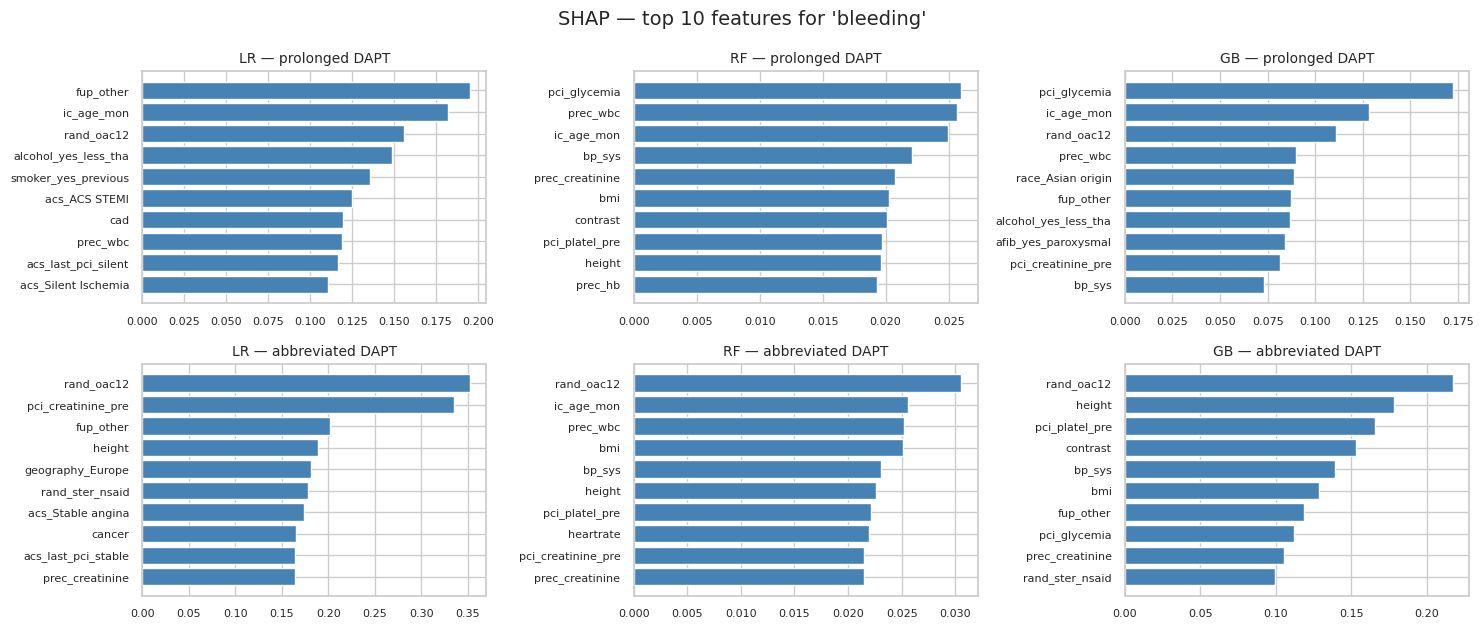

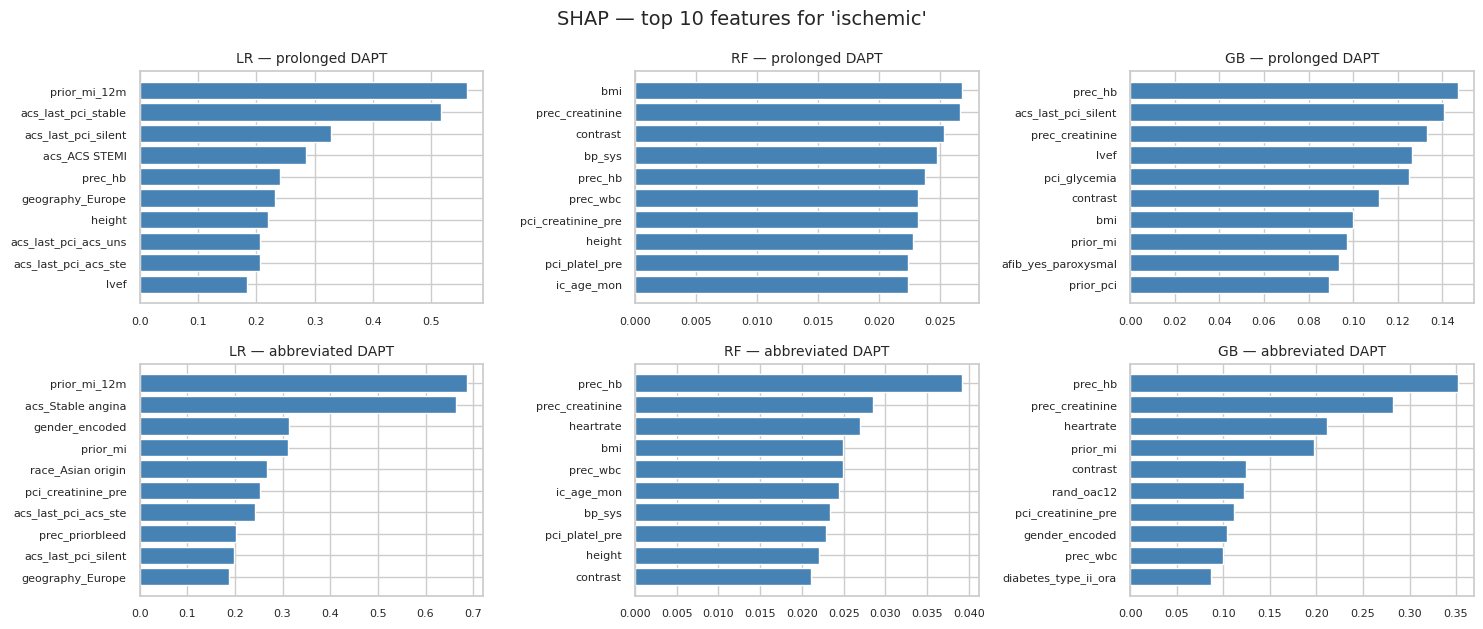

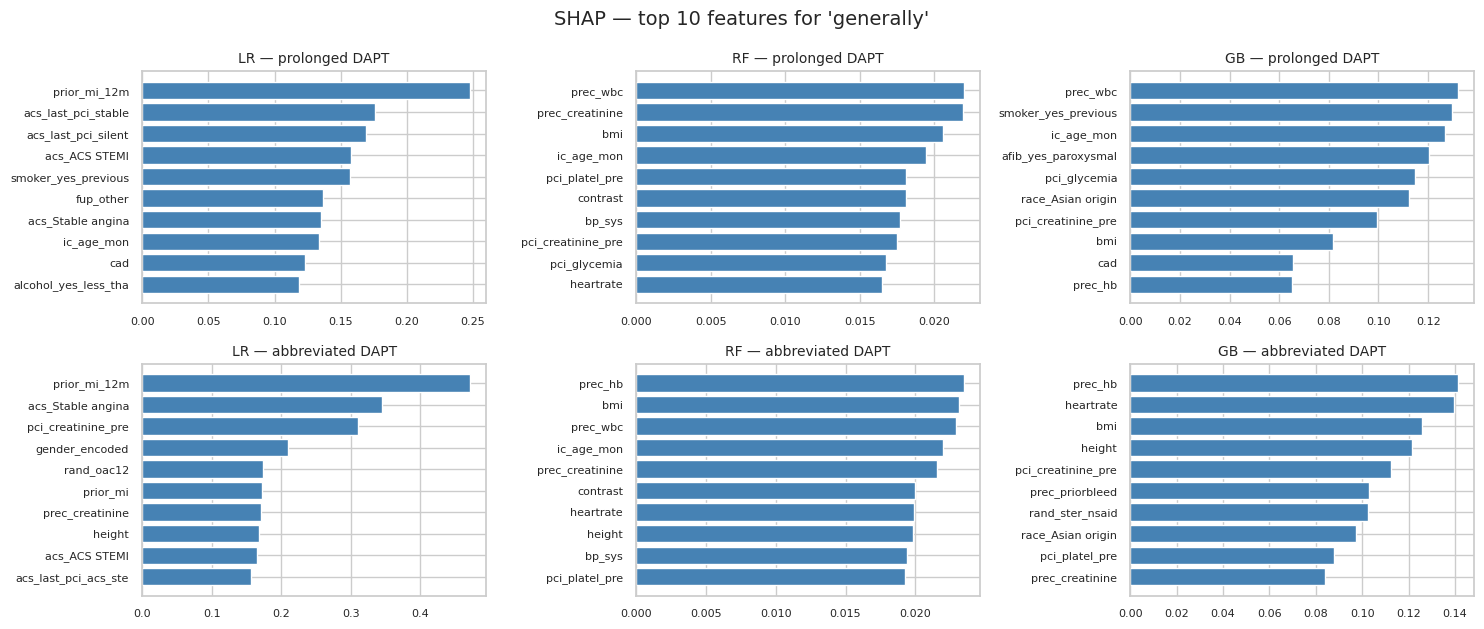

In [5]:
SHAP_SAMPLE_SIZE = 200
TOP_N_SHAP = 10
RNG = np.random.RandomState(42)


def get_shap_values(algo, estimator, background, X_eval):
    if algo == 'LR':
        explainer = shap.LinearExplainer(estimator, background)
    else:
        explainer = shap.TreeExplainer(estimator)
    sv = np.asarray(explainer.shap_values(X_eval))
    if sv.ndim == 3:  # (n_samples, n_features, n_classes) -> keep the positive class
        sv = sv[:, :, 1]
    return sv


def top_mean_abs_shap(shap_values, feature_names, top_n=TOP_N_SHAP):
    importance = np.abs(shap_values).mean(axis=0)
    order = np.argsort(importance)[::-1][:top_n]
    return [feature_names[i] for i in order], importance[order]


shap_top_features = {}  # (model_name, target) -> (feature_names, importances)

for model_name, info in models.items():
    X_train, X_test, y_train, y_test = DATA_VARIANTS[info['variant']]
    X_train_t, X_test_t, estimators = get_estimators_and_data(info['pipeline'], X_train, X_test)
    feature_names = X_train.columns.tolist()

    sample_idx = RNG.choice(X_test_t.shape[0], size=min(SHAP_SAMPLE_SIZE, X_test_t.shape[0]), replace=False)
    X_sample = X_test_t[sample_idx]

    for target, estimator in zip(TARGET_NAMES, estimators):
        shap_values = get_shap_values(info['algo'], estimator, X_train_t, X_sample)
        shap_top_features[(model_name, target)] = top_mean_abs_shap(shap_values, feature_names)

variant_order = [suffix for suffix in VARIANT_LABELS if any(i['variant'] == suffix for i in models.values())]
algo_order = [spec['algo'] for spec in ALGOS if any(i['algo'] == spec['algo'] for i in models.values())]

for target in TARGET_NAMES:
    fig, axes = plt.subplots(
        len(variant_order), len(algo_order),
        figsize=(5 * len(algo_order), 3.2 * len(variant_order)), squeeze=False,
    )
    fig.suptitle(f"SHAP — top {TOP_N_SHAP} features for '{target}'", fontsize=14)

    for r, suffix in enumerate(variant_order):
        for c, algo in enumerate(algo_order):
            ax = axes[r][c]
            model_name = f"{algo}_gf_multioutput{suffix}"
            if model_name not in models:
                ax.axis('off')
                continue
            feature_names, importances = shap_top_features[(model_name, target)]
            ax.barh(feature_names[::-1], importances[::-1], color='steelblue')
            ax.set_title(f"{algo} — {VARIANT_LABELS[suffix]}", fontsize=10)
            ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

### SHAP — Detailed Beeswarm Plots (per model)

The grid above ranks top features by mean absolute SHAP value, but loses the per-sample
detail (direction and spread of impact) that the full beeswarm plot shows. This section
reproduces that detailed view for every one of the 9 models × 3 targets, for anyone who needs
to drill into a specific model.

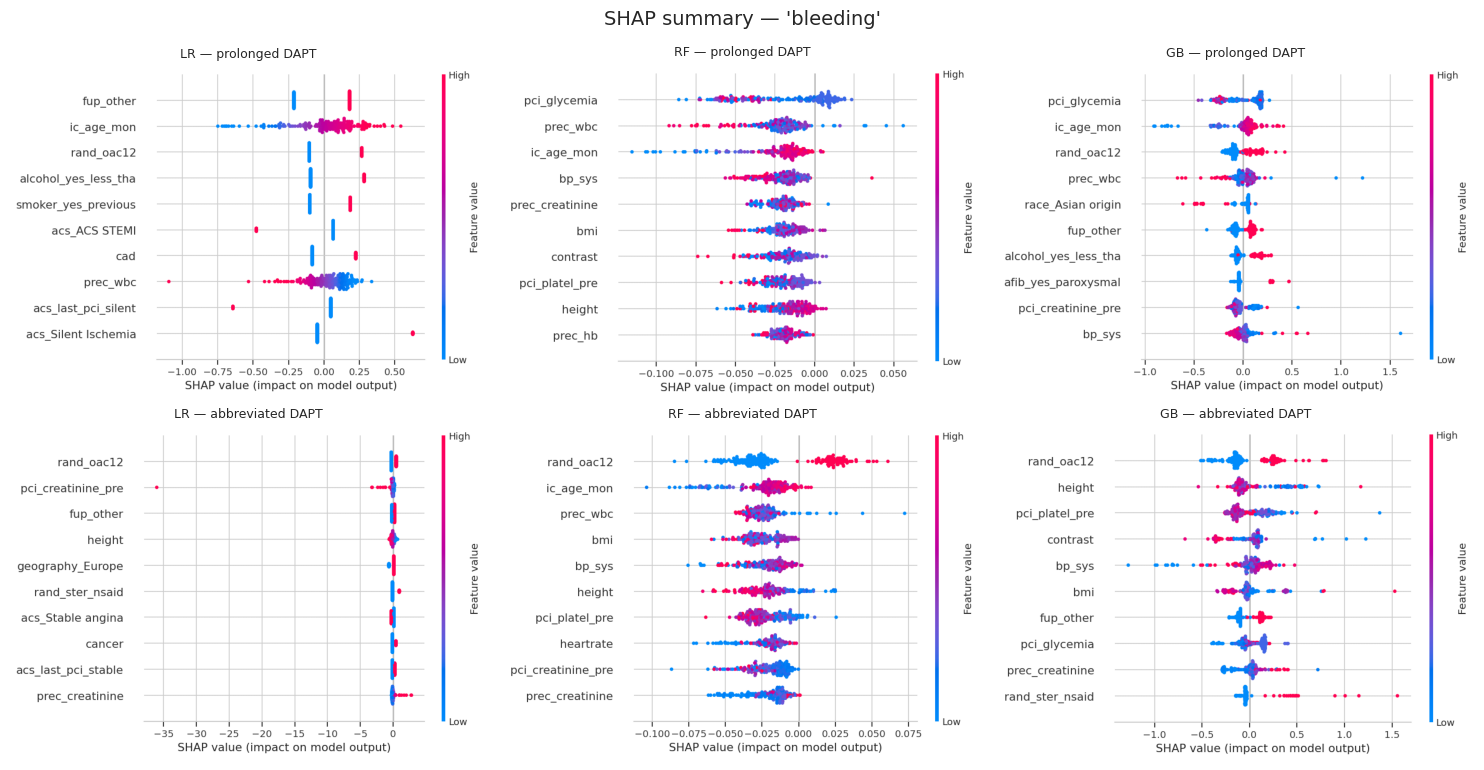

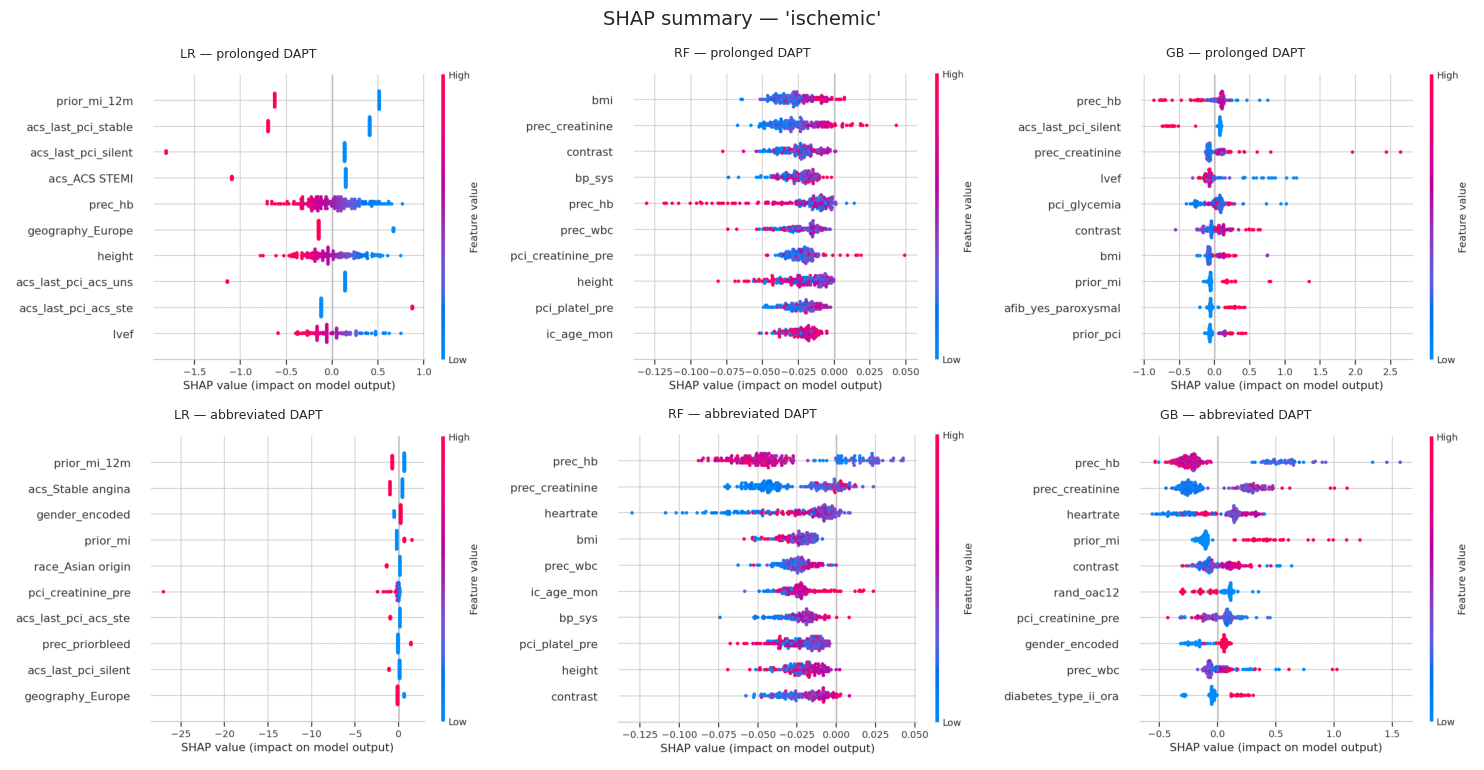

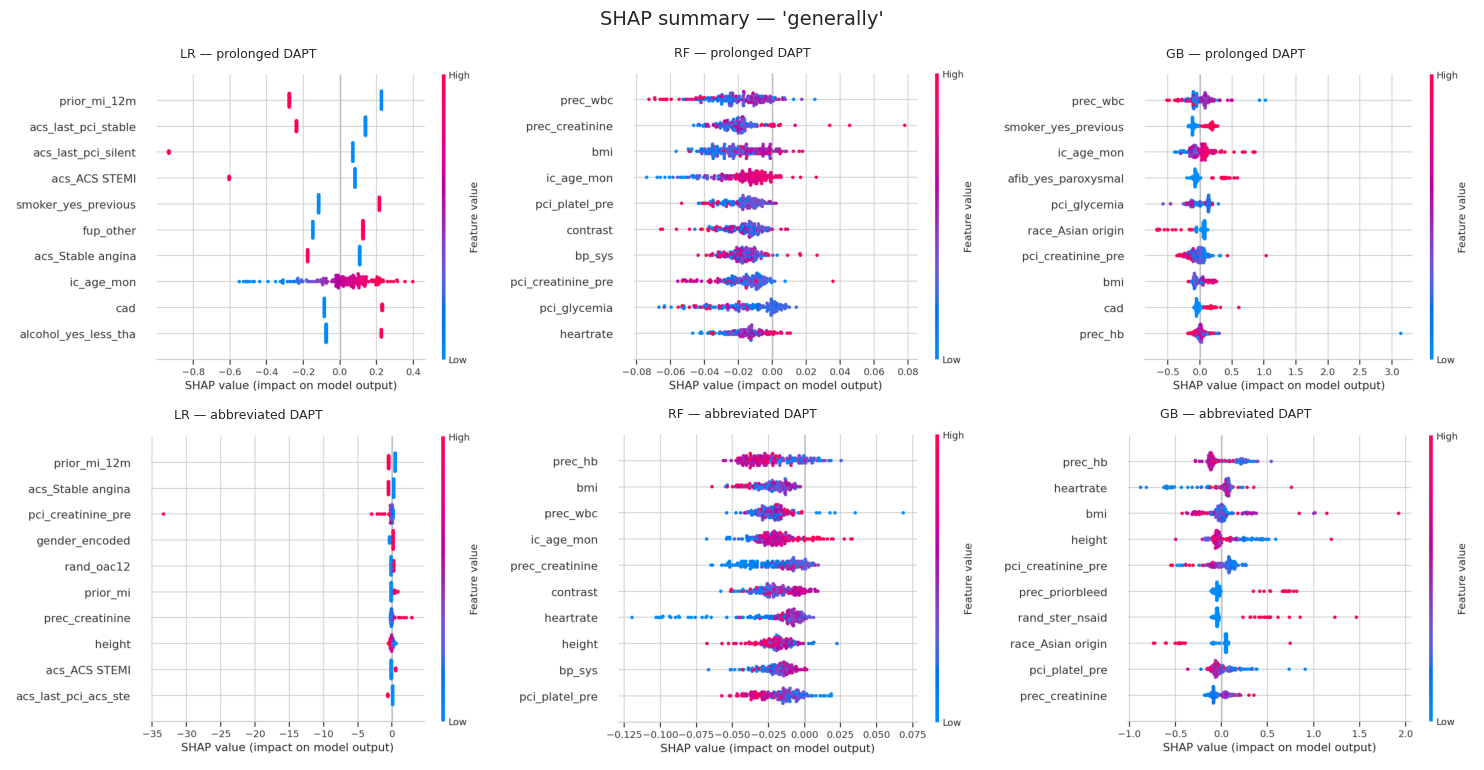

In [6]:
import io

SHAP_SAMPLE_SIZE = 200
TOP_N_SHAP      = 10
RNG             = np.random.RandomState(42)

# ── 1. Pre-calcolo SHAP values ────────────────────────────────────────────────
shap_store = {}   # (model_name, target) -> (shap_values, X_sample, feature_names)

for model_name, info in models.items():
    X_train, X_test, y_train, y_test = DATA_VARIANTS[info['variant']]
    X_train_t, X_test_t, estimators  = get_estimators_and_data(info['pipeline'], X_train, X_test)
    feature_names = X_train.columns.tolist()

    sample_idx = RNG.choice(X_test_t.shape[0], size=min(SHAP_SAMPLE_SIZE, X_test_t.shape[0]), replace=False)
    X_sample   = X_test_t[sample_idx]

    for target, estimator in zip(TARGET_NAMES, estimators):
        sv = get_shap_values(info['algo'], estimator, X_train_t, X_sample)
        shap_store[(model_name, target)] = (sv, X_sample, feature_names)

# ── 2. Pre-rendering buffer PNG (nessuna figura esterna aperta) ───────────────
shap_imgs = {}   # (model_name, target) -> np.array immagine

for (model_name, target), (sv, X_sample, feature_names) in shap_store.items():
    shap.summary_plot(sv, X_sample, feature_names=feature_names,
                      max_display=TOP_N_SHAP, show=False)
    shap_fig = plt.gcf()
    shap_fig.tight_layout()
    buf = io.BytesIO()
    shap_fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close(shap_fig)
    buf.seek(0)
    shap_imgs[(model_name, target)] = plt.imread(buf)

# ── 3. Griglia variant × algo, una figura per target ─────────────────────────
variant_order = [s for s in VARIANT_LABELS if any(i['variant'] == s for i in models.values())]
algo_order    = [s['algo'] for s in ALGOS    if any(i['algo'] == s['algo'] for i in models.values())]

for target in TARGET_NAMES:
    fig, axes = plt.subplots(
        len(variant_order), len(algo_order),
        figsize=(5 * len(algo_order), 4 * len(variant_order)), squeeze=False,
    )
    fig.suptitle(f"SHAP summary — '{target}'", fontsize=14)

    for r, suffix in enumerate(variant_order):
        for c, algo in enumerate(algo_order):
            ax = axes[r][c]
            model_name = f"{algo}_gf_multioutput{suffix}"

            if model_name not in models or (model_name, target) not in shap_imgs:
                ax.axis('off')
                continue

            ax.imshow(shap_imgs[(model_name, target)])
            ax.set_title(f"{algo} — {VARIANT_LABELS[suffix]}", fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## LIME — Local Explanations

Showing LIME for all 9 models × 3 targets (27 plots) is unreadable. Instead, for each cohort
variant we pick the **best-performing model** (highest mean F1 on the positive class across
the 3 targets, from the performance table above) and explain one held-out instance per
target — preferring a true positive so the explanation is informative, falling back to the
first test row if the target has no positive case in the held-out split. This gives 3 models ×
3 targets = 9 plots, organized as one compact grid per model.</cell id="c2c7ea3a">


Best model per cohort (mean F1 on positive class across targets):
  prolonged DAPT: GB_gf_multioutput_lDAPT  (F1=0.248)
  abbreviated DAPT: LR_gf_multioutput_sDAPT  (F1=0.204)


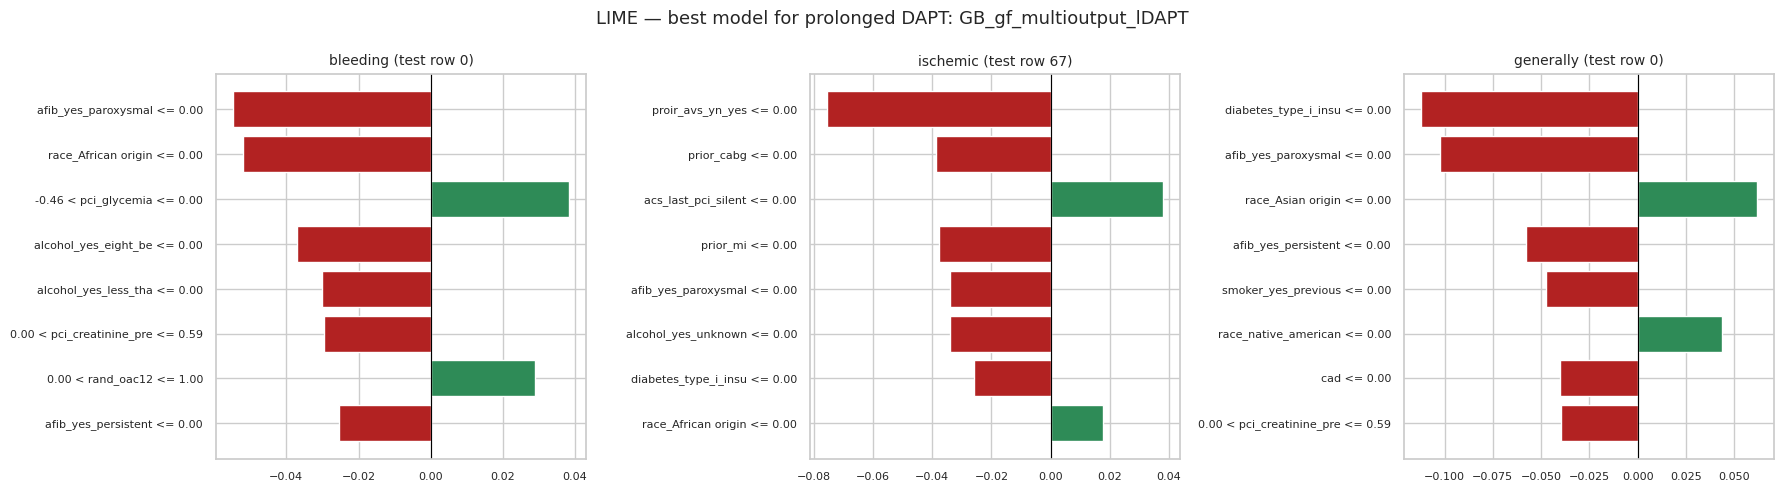

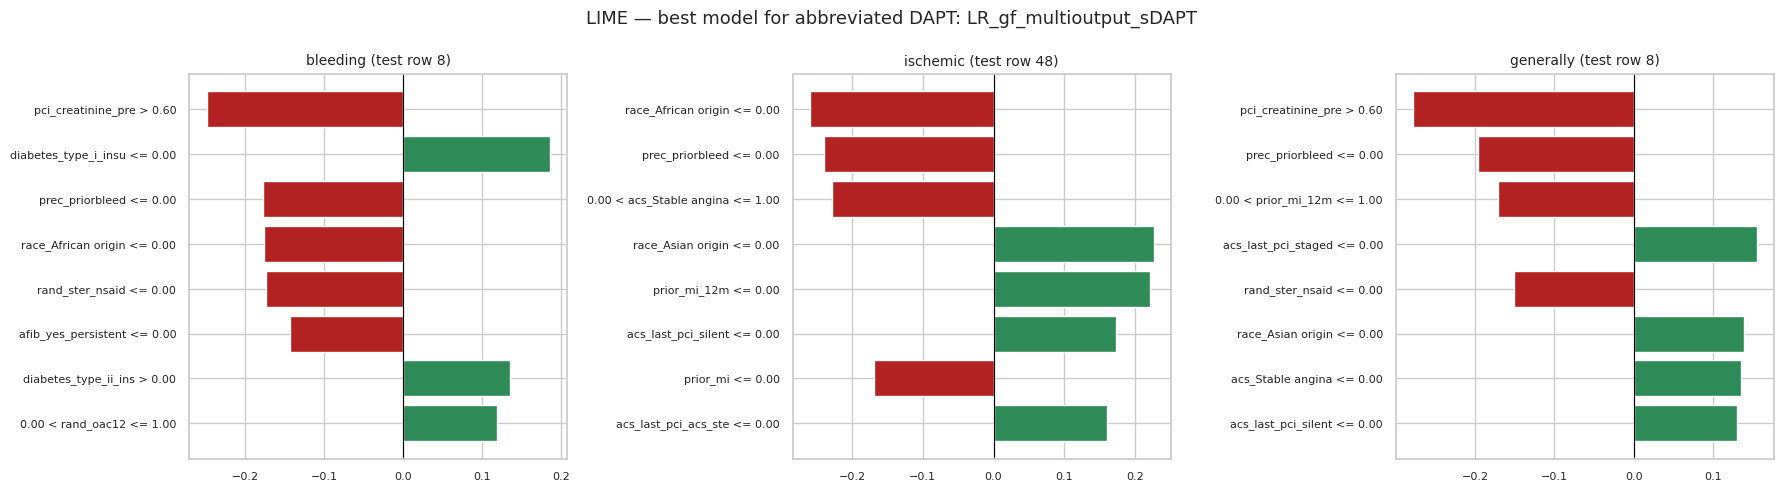

In [7]:
def pick_instance_index(y_test_col):
    positives = np.flatnonzero(y_test_col.to_numpy())
    return int(positives[0]) if len(positives) else 0


model_scores = {
    model_name: results_df.loc[(info['algo_label'], info['variant_label']),
                                [(t, 'f1') for t in TARGET_NAMES]].mean()
    for model_name, info in models.items()
}

best_per_variant = {}
for model_name, info in models.items():
    suffix = info['variant']
    if suffix not in best_per_variant or model_scores[model_name] > model_scores[best_per_variant[suffix]]:
        best_per_variant[suffix] = model_name

print("Best model per cohort (mean F1 on positive class across targets):")
for suffix, model_name in best_per_variant.items():
    print(f"  {VARIANT_LABELS[suffix]}: {model_name}  (F1={model_scores[model_name]:.3f})")

for suffix, model_name in best_per_variant.items():
    info = models[model_name]
    X_train, X_test, y_train, y_test = DATA_VARIANTS[suffix]
    X_train_t, X_test_t, estimators = get_estimators_and_data(info['pipeline'], X_train, X_test)
    feature_names = X_train.columns.tolist()

    explainer = LimeTabularExplainer(
        X_train_t, feature_names=feature_names,
        class_names=['no event', 'event'], mode='classification', random_state=42,
    )

    fig, axes = plt.subplots(1, len(TARGET_NAMES), figsize=(18, 5))
    fig.suptitle(f"LIME — best model for {info['variant_label']}: {model_name}", fontsize=13)

    for ax, target, estimator in zip(axes, TARGET_NAMES, estimators):
        idx = pick_instance_index(y_test[target])
        explanation = explainer.explain_instance(X_test_t[idx], estimator.predict_proba, num_features=8)
        exp_features, exp_weights = zip(*explanation.as_list())
        colors = ['firebrick' if w < 0 else 'seagreen' for w in exp_weights]

        ax.barh(exp_features[::-1], exp_weights[::-1], color=colors[::-1])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f"{target} (test row {idx})", fontsize=10)
        ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()